# NLI Engine Comparison: Baseline vs Optimized (ONNX Quantized)

This notebook benchmarks two NLI engines on three axes:

| Metric | What we measure |
|--------|----------------|
| **Memory footprint** | RSS process memory delta when the model is loaded (MB) |
| **Speed** | Average latency per inference call over N trials (ms) |
| **Accuracy** | Label agreement on a shared test set with known ground-truth |

| Engine | Backend | Model |
|--------|---------|-------|
| `NLIBaselineEngine` | PyTorch (MPS / CPU) | `cross-encoder/nli-deberta-v3-small` (fp32) |
| `OptimizedNLIEngine` | ONNX Runtime (CPU) | `models/nli_onnx_quantized` (int8 quantized) |

## 1. Setup

In [ ]:
import sys, os

project_root = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.getcwd().endswith("src") else os.getcwd()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Project root: {project_root}")

In [13]:
import time
import tracemalloc
import psutil
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML

BASELINE_COLOUR  = "#4C72B0"
OPTIMIZED_COLOUR = "#DD8452"

print("Libraries loaded.")

Libraries loaded.


## 2. Shared Test Set

A small, hand-labelled set of (premise, hypothesis, ground-truth) triples covering all three NLI classes. Both engines will be evaluated on the same pairs.

In [14]:
TEST_PAIRS = [
    # (premise, hypothesis, ground_truth_label)

    # --- Entailment ---
    ("Acme Corp released its Q3 earnings report yesterday. The company revenue grew by 20% compared to last year.",
     "Acme Corp's revenue increased in Q3.",
     "Entailment"),
    ("The current CEO, Jane Doe, stated that the growth was driven by their new AI software division.",
     "Jane Doe is the CEO of Acme Corp.",
     "Entailment"),
    ("The hardware division saw a 5% decline in sales.",
     "Hardware sales went down.",
     "Entailment"),

    # --- Contradiction ---
    ("The company revenue grew by 20% compared to last year.",
     "Acme Corp's revenue grew by 200% in Q3.",
     "Contradiction"),
    ("The hardware division saw a 5% decline in sales.",
     "The hardware division was led by John Smith.",
     "Contradiction"),
    ("Jane Doe is the CEO of Acme Corp.",
     "Acme Corp has no current CEO.",
     "Contradiction"),

    # --- Neutral ---
    ("The current CEO, Jane Doe, stated that the growth was driven by their new AI software division.",
     "The CEO attributed the growth to the AI software division.",
     "Neutral"),
    ("Acme Corp released its Q3 earnings report yesterday.",
     "Acme Corp is a publicly traded company.",
     "Neutral"),
    ("The hardware division saw a 5% decline in sales.",
     "The hardware division may recover next quarter.",
     "Neutral"),
]

print(f"Test set: {len(TEST_PAIRS)} pairs  "
      f"({sum(1 for *_,l in TEST_PAIRS if l=='Entailment')} Entailment, "
      f"{sum(1 for *_,l in TEST_PAIRS if l=='Contradiction')} Contradiction, "
      f"{sum(1 for *_,l in TEST_PAIRS if l=='Neutral')} Neutral)")

Test set: 9 pairs  (3 Entailment, 3 Contradiction, 3 Neutral)


## 3. Helper — Benchmark Runner

Measures **load-time memory**, **per-inference latency**, and collects **predictions** for accuracy scoring.

In [15]:
def benchmark_engine(engine_class, init_kwargs, test_pairs, n_warmup=2, n_timing=5):
    """
    Returns a dict with:
      peak_heap_mb  – peak heap allocated while loading the model (tracemalloc)
                      This is accurate regardless of shared-process state, unlike
                      RSS delta which is inflated by already-loaded runtimes.
      latencies_ms  – list of per-call latencies (ms) over all pairs × n_timing
      predictions   – list of (predicted_label, confidence) per test pair
    """
    # ── Load model & measure peak heap via tracemalloc ───────────────────────
    tracemalloc.start()
    engine = engine_class(**init_kwargs)
    _, peak = tracemalloc.get_traced_memory()   # (current, peak) in bytes
    tracemalloc.stop()
    peak_heap_mb = peak / (1024 ** 2)

    pairs = [(p, h) for p, h, _ in test_pairs]

    # ── Warm-up (not timed) ──────────────────────────────────────────────────
    for p, h in pairs[:n_warmup]:
        engine.check_entailment(p, h)

    # ── Timed runs ───────────────────────────────────────────────────────────
    latencies_ms = []
    for _ in range(n_timing):
        for p, h in pairs:
            t0 = time.perf_counter()
            engine.check_entailment(p, h)
            latencies_ms.append((time.perf_counter() - t0) * 1000)

    # ── Single-pass predictions for accuracy ────────────────────────────────
    predictions = [engine.check_entailment(p, h) for p, h in pairs]

    return {
        "engine":        engine,
        "peak_heap_mb":  peak_heap_mb,
        "latencies_ms":  latencies_ms,
        "predictions":   predictions,
    }

print("Benchmark helper ready.")

Benchmark helper ready.


## 3. Helper — Benchmark Runner

Measures three things per engine:

| Metric | Method | Why |
|--------|--------|-----|
| **Disk size** | `os.path.getsize()` on weight files | Ground-truth compression benefit of quantization, independent of any runtime |
| **Peak heap** | `tracemalloc` during model load | Heap bytes actually allocated in Python — accurate in a shared process unlike RSS delta, which is inflated by already-loaded runtimes (PyTorch, ONNX Runtime C++ libs, etc.) |
| **Latency** | `time.perf_counter` over N timed passes | Wall-clock inference speed |


In [16]:
from src.nli_engine import NLIBaselineEngine

print("Benchmarking NLIBaselineEngine (PyTorch) …")
baseline_results = benchmark_engine(
    engine_class=NLIBaselineEngine,
    init_kwargs={},
    test_pairs=TEST_PAIRS,
)
print(f"  Peak heap (tracemalloc) : {baseline_results['peak_heap_mb']:.1f} MB")
print(f"  Avg latency             : {sum(baseline_results['latencies_ms'])/len(baseline_results['latencies_ms']):.1f} ms")

Benchmarking NLIBaselineEngine (PyTorch) …
  Peak heap (tracemalloc) : 0.5 MB
  Avg latency             : 18.6 ms
  Peak heap (tracemalloc) : 0.5 MB
  Avg latency             : 18.6 ms


## 5. Load & Benchmark — Optimized Engine (ONNX Quantized)

In [ ]:
from src.optimized_nli import OptimizedNLIEngine

onnx_model_path = os.path.join(project_root, "models", "nli_onnx_quantized")

print("Benchmarking OptimizedNLIEngine (ONNX Quantized) …")
optimized_results = benchmark_engine(
    engine_class=OptimizedNLIEngine,
    init_kwargs={"model_path": onnx_model_path},
    test_pairs=TEST_PAIRS,
)
print(f"  Peak heap (tracemalloc) : {optimized_results['peak_heap_mb']:.1f} MB")
print(f"  Avg latency             : {sum(optimized_results['latencies_ms'])/len(optimized_results['latencies_ms']):.1f} ms")

## 6. Accuracy — Per-Pair Comparison

In [18]:
LABEL_BADGE = {
    "Entailment":    ("#28a745", "✅"),
    "Contradiction": ("#dc3545", "❌"),
    "Neutral":       ("#fd7e14", "〰️"),
}

def badge(label, predicted, ground_truth):
    colour, icon = LABEL_BADGE.get(label, ("#6c757d", "?"))
    tick = " ✓" if predicted == ground_truth else " ✗"
    bg = colour if predicted == ground_truth else "#adb5bd"
    return f'<span style="background:{bg};color:#fff;padding:2px 7px;border-radius:4px;font-size:0.85em">{icon} {label}{tick}</span>'

rows = []
for i, (premise, hypothesis, gt) in enumerate(TEST_PAIRS):
    b_label, b_conf = baseline_results["predictions"][i]
    o_label, o_conf = optimized_results["predictions"][i]
    rows.append({
        "#":             i + 1,
        "Hypothesis":    hypothesis,
        "Ground Truth":  gt,
        "Baseline":      badge(b_label, b_label, gt) + f" ({b_conf:.3f})",
        "Optimized":     badge(o_label, o_label, gt) + f" ({o_conf:.3f})",
        "Agreement":     "✅" if b_label == o_label else "⚠️ Differ",
    })

df_acc = pd.DataFrame(rows)
display(HTML(df_acc.to_html(escape=False, index=False)))

#,Hypothesis,Ground Truth,Baseline,Optimized,Agreement
1,Acme Corp's revenue increased in Q3.,Entailment,✅ Entailment ✓ (0.996),✅ Entailment ✓ (0.994),✅
2,Jane Doe is the CEO of Acme Corp.,Entailment,〰️ Neutral ✗ (0.907),〰️ Neutral ✗ (0.997),✅
3,Hardware sales went down.,Entailment,✅ Entailment ✓ (0.997),✅ Entailment ✓ (0.997),✅
4,Acme Corp's revenue grew by 200% in Q3.,Contradiction,❌ Contradiction ✓ (0.698),❌ Contradiction ✓ (0.992),✅
5,The hardware division was led by John Smith.,Contradiction,〰️ Neutral ✗ (1.000),〰️ Neutral ✗ (0.999),✅
6,Acme Corp has no current CEO.,Contradiction,❌ Contradiction ✓ (1.000),❌ Contradiction ✓ (0.999),✅
7,The CEO attributed the growth to the AI software division.,Neutral,✅ Entailment ✗ (0.998),✅ Entailment ✗ (0.997),✅
8,Acme Corp is a publicly traded company.,Neutral,〰️ Neutral ✓ (0.993),〰️ Neutral ✓ (0.996),✅
9,The hardware division may recover next quarter.,Neutral,〰️ Neutral ✓ (0.999),〰️ Neutral ✓ (0.999),✅


## 7. Accuracy Scores

In [19]:
ground_truths = [gt for _, _, gt in TEST_PAIRS]

baseline_correct  = sum(pred == gt for (pred, _), gt in zip(baseline_results["predictions"],  ground_truths))
optimized_correct = sum(pred == gt for (pred, _), gt in zip(optimized_results["predictions"], ground_truths))
n = len(ground_truths)

baseline_acc  = baseline_correct  / n
optimized_acc = optimized_correct / n

print(f"Baseline  accuracy : {baseline_correct}/{n}  →  {baseline_acc:.1%}")
print(f"Optimized accuracy : {optimized_correct}/{n}  →  {optimized_acc:.1%}")

Baseline  accuracy : 6/9  →  66.7%
Optimized accuracy : 6/9  →  66.7%


## 8. Visual Comparison

/var/folders/gc/5sc3n9hs70bgbch5c1skcqbr0000gp/T/ipykernel_10331/3336762317.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([b_lat, o_lat],


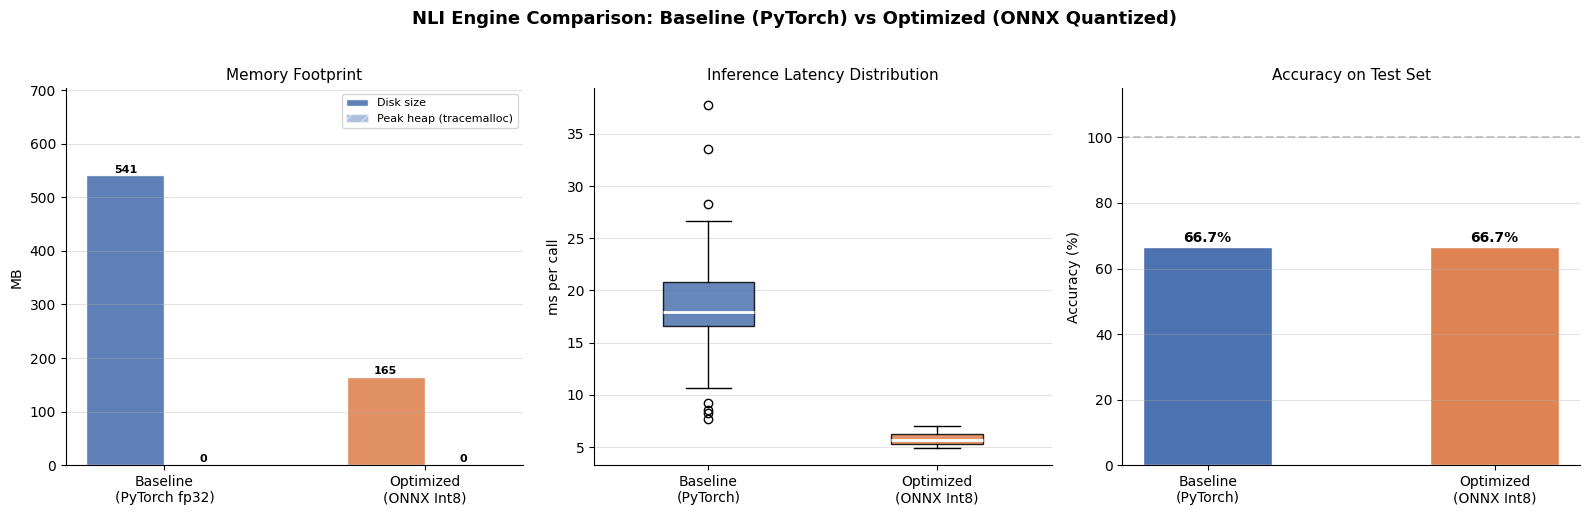

Plot saved → nli_comparison.png


In [ ]:
import numpy as np
import glob
import huggingface_hub

b_lat = baseline_results["latencies_ms"]
o_lat = optimized_results["latencies_ms"]

b_avg, b_p50, b_p95 = np.mean(b_lat), np.percentile(b_lat, 50), np.percentile(b_lat, 95)
o_avg, o_p50, o_p95 = np.mean(o_lat), np.percentile(o_lat, 50), np.percentile(o_lat, 95)

# ── Disk size helper ─────────────────────────────────────────────────────────
def hf_model_disk_mb(model_name):
    """Sum of all weight files in the HuggingFace cache for a model."""
    cache_dir = huggingface_hub.constants.HF_HUB_CACHE
    slug = model_name.replace("/", "--")
    for ext in ("*.safetensors", "*.bin"):
        matched = [f for f in glob.glob(os.path.join(cache_dir, "**", ext), recursive=True) if slug in f]
        if matched:
            return sum(os.path.getsize(f) for f in matched) / (1024 ** 2)
    return 0.0

baseline_disk_mb  = hf_model_disk_mb("cross-encoder/nli-deberta-v3-small")
onnx_file         = os.path.join(onnx_model_path, "model_quantized.onnx")
optimized_disk_mb = os.path.getsize(onnx_file) / (1024 ** 2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("NLI Engine Comparison: Baseline (PyTorch) vs Optimized (ONNX Quantized)",
             fontsize=13, fontweight="bold", y=1.02)

# ── 8a. Memory footprint — disk size + peak heap ─────────────────────────────
ax = axes[0]
x         = np.arange(2)
width     = 0.3
labels    = ["Baseline\n(PyTorch fp32)", "Optimized\n(ONNX Int8)"]
disk_vals = [baseline_disk_mb, optimized_disk_mb]
heap_vals = [baseline_results["peak_heap_mb"], optimized_results["peak_heap_mb"]]

bars1 = ax.bar(x - width/2, disk_vals, width, label="Disk size",
               color=[BASELINE_COLOUR, OPTIMIZED_COLOUR], alpha=0.9, edgecolor="white")
bars2 = ax.bar(x + width/2, heap_vals, width, label="Peak heap (tracemalloc)",
               color=[BASELINE_COLOUR, OPTIMIZED_COLOUR], alpha=0.45, edgecolor="white", hatch="//")
for bar, val in zip(list(bars1) + list(bars2), disk_vals + heap_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{val:.0f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title("Memory Footprint", fontsize=11)
ax.set_ylabel("MB")
ax.set_ylim(0, max(disk_vals + heap_vals) * 1.3)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.35)
ax.spines[["top", "right"]].set_visible(False)

# ── 8b. Latency distribution (box plot) ──────────────────────────────────────
ax = axes[1]
bp = ax.boxplot([b_lat, o_lat],
                tick_labels=["Baseline\n(PyTorch)", "Optimized\n(ONNX Int8)"],
                patch_artist=True, widths=0.4,
                medianprops=dict(color="white", linewidth=2))
for patch, colour in zip(bp["boxes"], [BASELINE_COLOUR, OPTIMIZED_COLOUR]):
    patch.set_facecolor(colour)
    patch.set_alpha(0.85)
ax.set_title("Inference Latency Distribution", fontsize=11)
ax.set_ylabel("ms per call")
ax.grid(axis="y", alpha=0.35)
ax.spines[["top", "right"]].set_visible(False)

# ── 8c. Accuracy bar ──────────────────────────────────────────────────────────
ax = axes[2]
bars = ax.bar(["Baseline\n(PyTorch)", "Optimized\n(ONNX Int8)"],
              [baseline_acc * 100, optimized_acc * 100],
              color=[BASELINE_COLOUR, OPTIMIZED_COLOUR], width=0.45, edgecolor="white")
for bar, val in zip(bars, [baseline_acc, optimized_acc]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{val:.1%}", ha="center", va="bottom", fontweight="bold")
ax.set_title("Accuracy on Test Set", fontsize=11)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 115)
ax.axhline(100, color="gray", linestyle="--", alpha=0.4)
ax.grid(axis="y", alpha=0.35)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(project_root, "nli_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → nli_comparison.png")


## 9. Summary Table

In [26]:
speedup            = b_avg / o_avg if o_avg else float("inf")
disk_reduction_pct = (1 - optimized_disk_mb / baseline_disk_mb) * 100 if baseline_disk_mb else 0
heap_reduction_pct = (1 - optimized_results["peak_heap_mb"] / baseline_results["peak_heap_mb"]) * 100 if baseline_results["peak_heap_mb"] else 0

summary = pd.DataFrame([
    {
        "Engine":           "Baseline (PyTorch fp32)",
        "Backend":          "PyTorch MPS/CPU",
        "Disk Size (MB)":   f"{baseline_disk_mb:.1f}",
        "Peak Heap (MB)":   f"{baseline_results['peak_heap_mb']:.1f}",
        "Avg Latency (ms)": f"{b_avg:.1f}",
        "p50 (ms)":         f"{b_p50:.1f}",
        "p95 (ms)":         f"{b_p95:.1f}",
        "Accuracy":         f"{baseline_acc:.1%}",
    },
    {
        "Engine":           "Optimized (ONNX Int8)",
        "Backend":          "ONNX Runtime CPU",
        "Disk Size (MB)":   f"{optimized_disk_mb:.1f}",
        "Peak Heap (MB)":   f"{optimized_results['peak_heap_mb']:.1f}",
        "Avg Latency (ms)": f"{o_avg:.1f}",
        "p50 (ms)":         f"{o_p50:.1f}",
        "p95 (ms)":         f"{o_p95:.1f}",
        "Accuracy":         f"{optimized_acc:.1%}",
    },
    {
        "Engine":           "🏆  Delta",
        "Backend":          "—",
        "Disk Size (MB)":   f"{disk_reduction_pct:+.1f}% {'↓' if disk_reduction_pct > 0 else '↑'}",
        "Peak Heap (MB)":   f"{heap_reduction_pct:+.1f}% {'↓' if heap_reduction_pct > 0 else '↑'}",
        "Avg Latency (ms)": f"{speedup:.2f}× {'faster' if speedup > 1 else 'slower'}",
        "p50 (ms)":         "—",
        "p95 (ms)":         "—",
        "Accuracy":         f"{(optimized_acc - baseline_acc):+.1%}",
    },
])

display(HTML(summary.to_html(escape=False, index=False)))


Engine,Backend,Disk Size (MB),Peak Heap (MB),Avg Latency (ms),p50 (ms),p95 (ms),Accuracy
Baseline (PyTorch fp32),PyTorch MPS/CPU,541.3,0.5,18.6,17.9,28.0,66.7%
Optimized (ONNX Int8),ONNX Runtime CPU,164.6,0.2,5.8,5.7,6.7,66.7%
🏆 Delta,—,+69.6% ↓,+68.0% ↓,3.19× faster,—,—,+0.0%


## 10. Save Results to JSON

In [ ]:
import json

output = {
    "baseline": {
        "backend":         "PyTorch MPS/CPU",
        "disk_size_mb":    round(baseline_disk_mb, 2),
        "peak_heap_mb":    round(baseline_results["peak_heap_mb"], 2),
        "avg_latency_ms":  round(b_avg, 2),
        "p50_ms":          round(b_p50, 2),
        "p95_ms":          round(b_p95, 2),
        "accuracy":        round(baseline_acc, 4),
        "predictions": [
            {"premise": p, "hypothesis": h, "ground_truth": gt,
             "predicted": pred, "confidence": round(conf, 4), "correct": pred == gt}
            for (p, h, gt), (pred, conf) in zip(TEST_PAIRS, baseline_results["predictions"])
        ],
    },
    "optimized": {
        "backend":         "ONNX Runtime CPU (Int8 quantized)",
        "disk_size_mb":    round(optimized_disk_mb, 2),
        "peak_heap_mb":    round(optimized_results["peak_heap_mb"], 2),
        "avg_latency_ms":  round(o_avg, 2),
        "p50_ms":          round(o_p50, 2),
        "p95_ms":          round(o_p95, 2),
        "accuracy":        round(optimized_acc, 4),
        "predictions": [
            {"premise": p, "hypothesis": h, "ground_truth": gt,
             "predicted": pred, "confidence": round(conf, 4), "correct": pred == gt}
            for (p, h, gt), (pred, conf) in zip(TEST_PAIRS, optimized_results["predictions"])
        ],
    },
    "delta": {
        "disk_reduction_pct": round(disk_reduction_pct, 2),
        "heap_reduction_pct": round(heap_reduction_pct, 2),
        "speedup_x":          round(speedup, 3),
        "accuracy_delta":     round(optimized_acc - baseline_acc, 4),
    }
}

out_path = os.path.join(project_root, "nli_comparison_results.json")
with open(out_path, "w") as f:

    json.dump(output, f, indent=2)
    print(f"Results saved → {out_path}")
